# Customer Churn Prediction

## Objective
Predict whether a customer is likely to leave the service using machine learning.

## Business Value
Helps companies identify high-risk customers early and take retention actions such as discounts, loyalty plans, or service improvements.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("customer_churn.csv")

df.head()
df.shape

(500, 9)

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

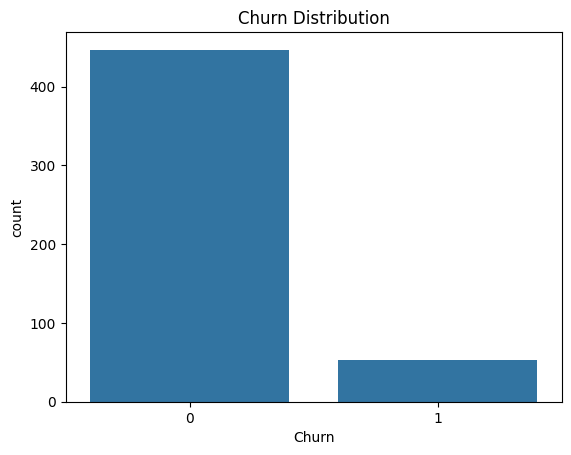

In [7]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

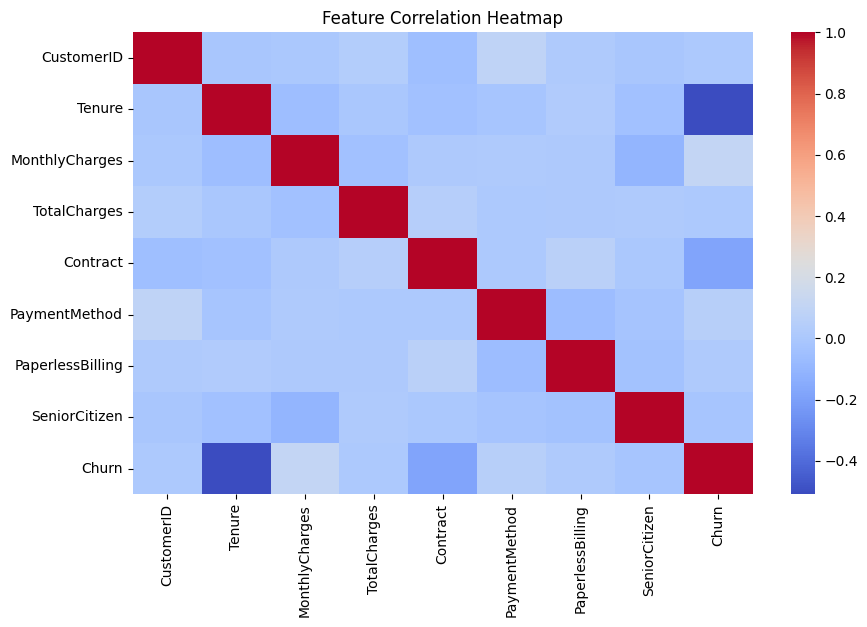

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

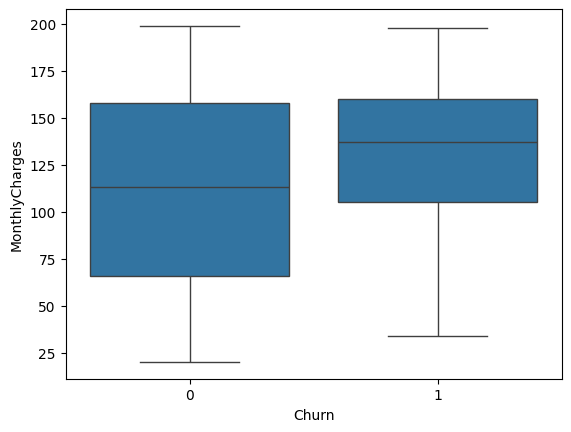

In [9]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

In [13]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_preds))

Random Forest Accuracy: 0.96


In [14]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

Logistic Regression Accuracy: 0.95
Random Forest Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        84
           1       1.00      0.75      0.86        16

    accuracy                           0.96       100
   macro avg       0.98      0.88      0.92       100
weighted avg       0.96      0.96      0.96       100



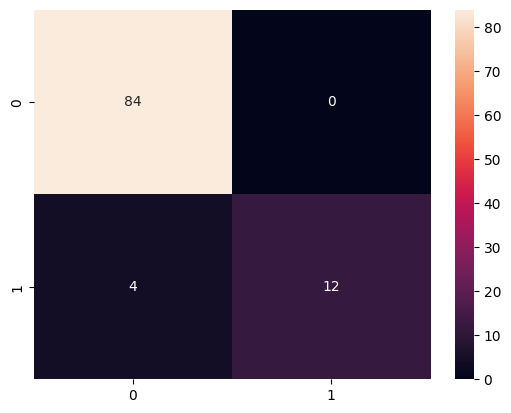

0.875

In [16]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_preds))
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))
sns.heatmap(confusion_matrix(y_test, rf_preds),
            annot=True,
            fmt='d')
plt.show()
roc_auc_score(y_test, rf_preds)

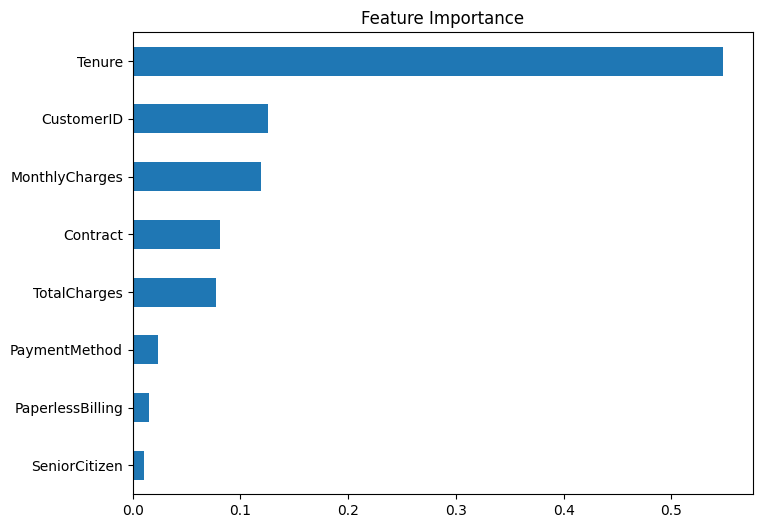

In [17]:
importance = pd.Series(rf.feature_importances_,
                       index=df.drop("Churn", axis=1).columns)

importance.sort_values().plot(kind="barh",
                              figsize=(8,6))

plt.title("Feature Importance")
plt.show()


## Key Insights

Customers with higher monthly charges are more likely to churn.

Customers with shorter tenure show higher churn probability.

Contract type strongly influences retention.

## Business Recommendation

Offer loyalty plans to short-tenure customers.

Provide discounts to high monthly charge customers.

Promote long-term contracts.

In [19]:
import pickle

pickle.dump(rf, open("churn_model.pkl", "wb"))